# Unsupervised Learning & PCA with Logistic Regression

This notebook demonstrates key concepts of unsupervised learning through Principal
Component Analysis (PCA) and then compares the performance of a Logistic Regression
classifier when trained on the original standardized data versus on the PCA–reduced data.

In this notebook, we cover:

1. **Overview of Unsupervised Learning & PCA**  
   - We explain why unsupervised methods are used when there is no response variable.
   - PCA is introduced as a method to reduce dimensionality by finding linear combinations
     of the features that capture maximum variance.
   - The mathematical ideas behind PCA are briefly discussed (centering, scaling, loadings, scores, and
     the proportion of variance explained).

2. **Data Preprocessing**  
   - The Breast Cancer dataset is used as an example.
   - The features are centered and scaled since PCA is sensitive to the scale of the variables.

3. **PCA Computation and Visualization**  
   - We compute PCA to reduce the data to two dimensions.
   - A scatter plot of the principal component scores is generated.
   - A biplot is created to visualize both the scores and the feature loadings.
   - A scree plot is generated to display the cumulative proportion of variance explained.

4. **Logistic Regression**  
   - We split the dataset into training and testing sets.
   - A Logistic Regression model is trained on both:
       a) the original standardized features, and
       b) the two-dimensional PCA–reduced features.
   - The accuracy scores of both models are computed and printed for comparison.

Let's begin by importing the necessary libraries and performing the analysis.

In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Step 1: Load and Preprocess the Data

We begin by loading the Breast Cancer dataset.
- The Breast Cancer dataset contains measurements for benign and malignant tumors.
- Here, the dataset provides:
    - `X` as a feature matrix
    - `y` as a target variable

In [ ]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data  # Feature matrix
y = breast_cancer.target  # Target variable (diagnosis)
feature_names = breast_cancer.feature_names
target_names = breast_cancer.target_names

print(y)
pd.DataFrame(X, columns = [feature_names])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Since PCA is sensitive to the scale of the variables, we must center and scale
the data.
- Centering ensures that each feature has a mean of zero, and scaling
ensures that each feature has unit variance.
- This prevents features with larger
numerical ranges from dominating the PCA results.

In [ ]:
from sklearn.preprocessing import StandardScaler

# It is important to center and scale the features since PCA is sensitive to the variable scales.
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

## Step 2: Compute PCA

In this step, we compute Principal Component Analysis (PCA) on the standardized data.
PCA seeks to find new axes (principal components) that maximize the variance of the data.
Each principal component is a linear combination of the original features.

**Key Points:**
- **Dimensionality Reduction:**  
  PCA reduces the dimensionality of the data while retaining as much of the variance as possible.
- **How It Works:**  
  The first principal component is the direction along which the data vary the most.
  Subsequent components are chosen to be orthogonal (uncorrelated) to the previous ones and
  capture the remaining variance.
- **Why Two Components:**  
  For visualization purposes, we reduce the data to 2 dimensions. This allows us to create 2D plots
  that illustrate the distribution of data points and the influence of the original features.

Below, we reduce the data to 2 components using the `PCA` class from scikit-learn and print the
explained variance ratio, which tells us the proportion of total variance captured by each component.

In [ ]:
from sklearn.decomposition import PCA

# We reduce the data to 2 components for visualization and further analysis.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Display the Explained Variance Ratio (i.e., the proportion of variance explained by each component)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Explained Variance:", np.cumsum(explained_variance))

Explained Variance Ratio: [0.44272026 0.18971182]
Cumulative Explained Variance: [0.44272026 0.63243208]


## Step 3: Visualizing the PCA results

PCA projects the data into fewer dimensions, which means we can plot it. We will build three
visualizations, each answering a different question:

1. **Scatter Plot of PCA Scores:** Where do the observations land in the new coordinate system defined by the first two principal components? Do distinct groups emerge?

2. **PCA Loadings Chart:** What does each axis mean? The loadings show how much each original feature contributes to each component, and in which direction.

3. **Scree plot:** How many components do we actually need? Plotting cumulative explained variance against the number of components reveals where adding another component stops buying meaningful information (the "elbow" in the curve).

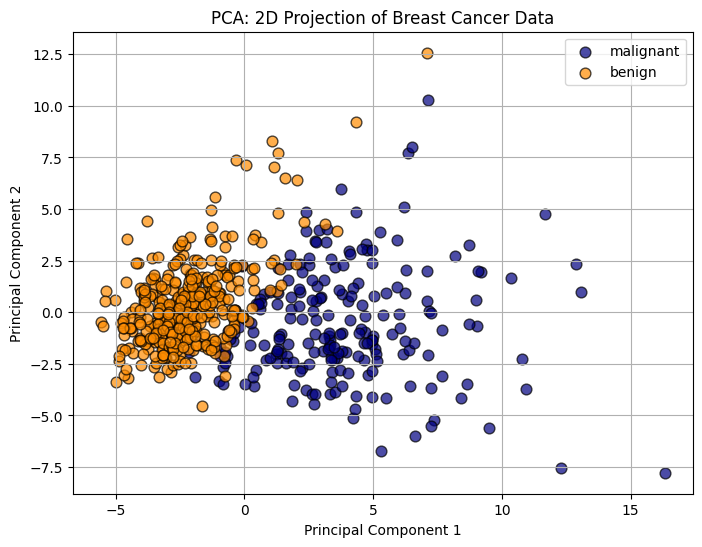

In [ ]:
# 3a. Scatter Plot of PCA Scores
plt.figure(figsize=(8, 6))
colors = ['navy', 'darkorange']
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=0.7,
                label=target_name, edgecolor='k', s=60)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: 2D Projection of Breast Cancer Data')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### PCA Loadings: How Features Contribute to Principal Components

Each principal component is a weighted combination of all 30 original features. The loadings below show the recipe: how much each feature contributes to each component, and in which direction. A positive loading means that higher values of a given feature push a sample's score up along that component's axis. A negative loading does the opposite.

The loadings are stored in `pca.components_`, where each row corresponds to a principal component and each column to a feature.

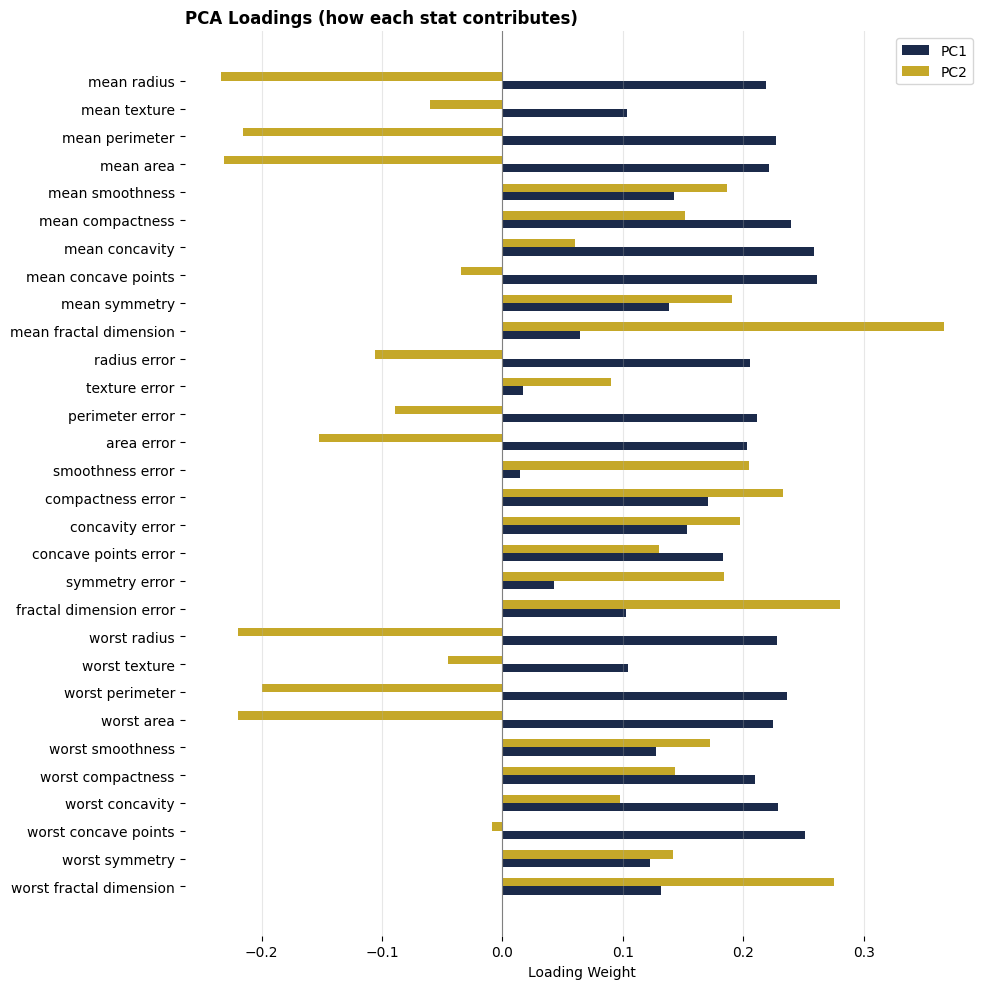

In [ ]:
# PCA Loadings: Horizontal Grouped Bar Chart

# Build a DataFrame from pca.components_ (shape: n_components x n_features).
# Each row is a principal component; each column is a feature's loading weight.
loadings_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Set up positions for the horizontal bars — one slot per feature
features = loadings_df.columns.tolist()
y_pos = np.arange(len(features))
bar_height = 0.3  # Controls how thick each bar is

fig, ax = plt.subplots(figsize=(10, 10))

# Plot PC1 and PC2 loadings side by side for each feature.
# We offset each set by half the bar height so they don't overlap.
ax.barh(y_pos + bar_height/2, loadings_df.loc['PC1'], bar_height,
        label='PC1', color='#1b2a4a', edgecolor='none')
ax.barh(y_pos - bar_height/2, loadings_df.loc['PC2'], bar_height,
        label='PC2', color='#c5a829', edgecolor='none')

# Label the y-axis with feature names and the x-axis with loading weight
ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.set_xlabel('Loading Weight')
ax.set_title('PCA Loadings (how each stat contributes)', fontweight='bold', loc='left')

# Add a vertical reference line at 0 so we can see positive vs. negative loadings
ax.axvline(0, color='grey', linewidth=0.8)

ax.legend(loc='upper right', frameon=True)
ax.invert_yaxis()          # Put the first feature at the top of the chart
ax.grid(axis='x', alpha=0.3)
ax.set_frame_on(False)     # Remove the border box for a cleaner look
plt.tight_layout()
plt.show()

**How to read the loadings:**
The sign of a loading is relative, not absolute. What matters is the contrast: features with positive loadings move together in one direction, and features with negative loadings move together in the other. When a component loads size features positively and irregularity features negatively, it is building an axis that separates those two groups. Note, too, that the signs can flip entirely between runs (all positive becomes all negative) without changing
the interpretation, because flipping every coefficient simply mirrors the axis. It is the pattern of which features cluster together that carries the meaning.

With that in mind, consider what each component picks up in this dataset:

- **PC1** loads most heavily on size and shape features: mean radius, mean perimeter, mean area, and their "worst" counterparts all carry strong weights in the same direction. This component is, in effect, a tumor-size axis. Large tumors score high; small tumors score low.

- **PC2** draws on a different set of features. Fractal dimension, texture, smoothness, and symmetry load more strongly here, while the dominant size features contribute less. This axis separates tumors by surface-level complexity rather than overall magnitude.

**The two components together produce the 2D map we saw in the scatter plot above: one axis sorts tumors by how large they are, the other by how irregular they look. That is why the malignant and benign clusters separate as cleanly as they do.**

### Scree Plot: Cumulative Explained Variance

The scree plot displays the cumulative proportion of variance explained by the principal components.
It is a valuable tool for deciding how many components to retain for further analysis:
- **Elbow Method:**  
  Look for the "elbow" in the plot—beyond this point, additional components contribute only
  marginal gains in explained variance.
- **Interpretation:**  
  In our case, reducing the Breast Cancer data to 2 components explains a significant portion of the variance,
  which justifies our choice for visualization.

Below, we compute PCA without specifying the number of components to generate the full cumulative
explained variance plot.

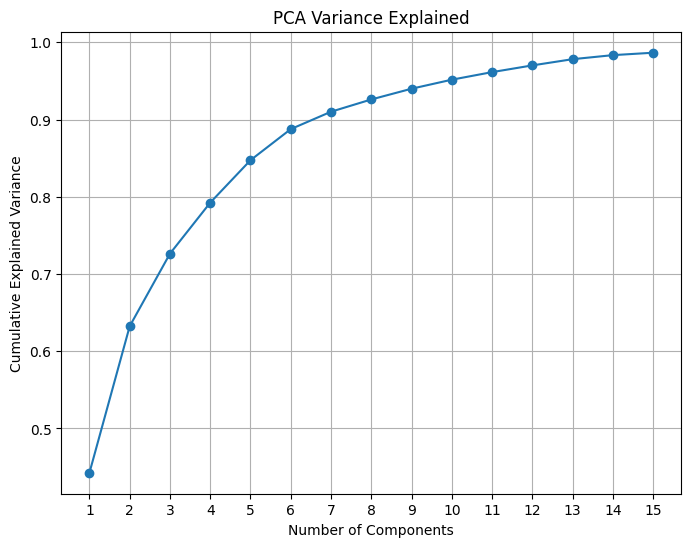

In [ ]:
# 3c. Scree Plot: Cumulative Explained Variance
# This plot helps in determining how many components to retain (looking for the "elbow")
pca_full = PCA(n_components = 15).fit(X_std)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Explained')
plt.xticks(range(1, len(cumulative_variance)+1))
plt.grid(True)
plt.show()

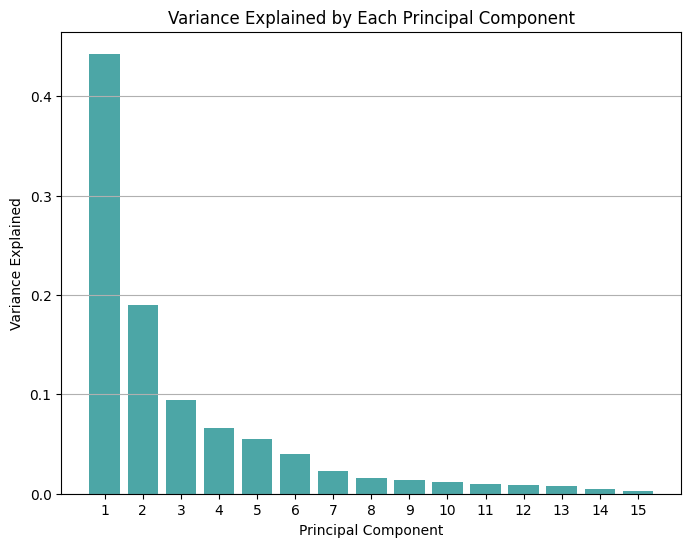

In [ ]:
# 3d. Bar Plot: Variance Explained by Each Component
plt.figure(figsize=(8, 6))
components = range(1, len(pca_full.explained_variance_ratio_) + 1)
plt.bar(components, pca_full.explained_variance_ratio_, alpha=0.7, color='teal')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Each Principal Component')
plt.xticks(components)
plt.grid(True, axis='y')
plt.show()

In [ ]:
explained = pca_full.explained_variance_ratio_ * 100  # individual variance (%) per component
components = np.arange(1, len(explained) + 1)
cumulative = np.cumsum(explained)

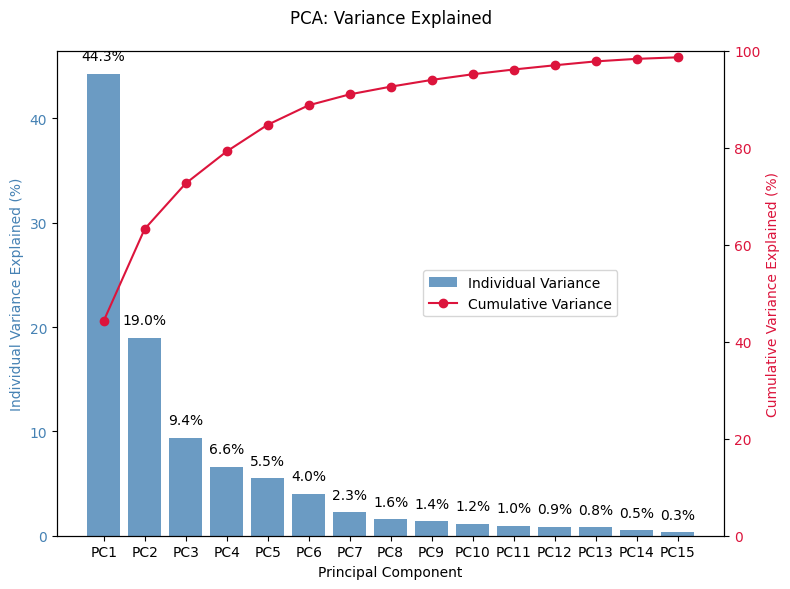

In [ ]:
 # Create the combined plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Bar plot for individual variance explained
bar_color = 'steelblue'
ax1.bar(components, explained, color=bar_color, alpha=0.8, label='Individual Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Individual Variance Explained (%)', color=bar_color)
ax1.tick_params(axis='y', labelcolor=bar_color)
ax1.set_xticks(components)
ax1.set_xticklabels([f"PC{i}" for i in components])

# Add percentage labels on each bar
for i, v in enumerate(explained):
    ax1.text(components[i], v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=10, color='black')

# Create a second y-axis for cumulative variance explained
ax2 = ax1.twinx()
line_color = 'crimson'
ax2.plot(components, cumulative, color=line_color, marker='o', label='Cumulative Variance')
ax2.set_ylabel('Cumulative Variance Explained (%)', color=line_color)
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.set_ylim(0, 100)

# Remove grid lines
ax1.grid(False)
ax2.grid(False)

# Combine legends from both axes and position the legend inside the plot (middle right)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', bbox_to_anchor=(0.85, 0.5))

plt.title('PCA: Variance Explained', pad=20)
plt.tight_layout()
plt.show()



---



## Step 4: Logistic Regression Classification Comparison

Finally, we explore how the data representation affects supervised learning by comparing a Logistic Regression's performance on:
- **The Original Standardized Data:**  
  This is our baseline, using the full feature set.
- **The PCA–Reduced Data:**  
  Here, we use only the two principal components obtained from PCA.

**Procedure:**
1. Split the dataset (both the standardized and PCA–reduced versions) into training and test sets.
2. Train a Logistic Regression on each version.
3. Evaluate and compare their accuracy on the test data.

This exercise shows how dimensionality reduction via PCA might simplify the model while still
capturing most of the signal, though some loss in accuracy is possible.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the standardized (original) data into training and test sets
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)

# Split the PCA-reduced data into training and test sets (using the same random state)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.2, random_state=42)

In [ ]:
# 4a. Logistic Regression on Original Data
clf_orig = LogisticRegression()
clf_orig.fit(X_train_orig, y_train)
y_pred_orig = clf_orig.predict(X_test_orig)
acc_orig = accuracy_score(y_test, y_pred_orig)
print("Logistic Regression Accuracy on Original Data: {:.2f}%".format(acc_orig * 100))

Logistic Regression Accuracy on Original Data: 97.37%


In [ ]:
# 4a. Logistic Regression on PCA Data
clf_pca = LogisticRegression()
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
print("Logistic Regression Accuracy on PCA Data: {:.2f}%".format(acc_pca * 100))

Logistic Regression Accuracy on PCA Data: 99.12%


### Discussion

- **PCA Visualization:**  
  The scatter plot and biplot help us understand how the original high-dimensional data is
  projected onto two principal components, and how each original feature contributes to these
  components.

- **Explained Variance & Scree Plot:**  
  The explained variance ratios indicate the proportion of total variance captured by each
  component. The scree plot shows the cumulative variance, guiding us in selecting the number
  of components to retain.

- **Classifier Comparison:**  
  The Logistic Regression model is applied to both the original standardized data and the PCA–reduced
  data. By comparing the accuracy scores, we can assess the impact of dimensionality reduction on
  the classifier’s performance.

This notebook not only reinforces the theory behind PCA but also demonstrates its practical applications,
including how reduced representations can be used in downstream supervised learning tasks.